# 02. Modelado Predictivo Avanzado (Enfoque Academico)

## 1. Introduccion
En esta segunda fase, utilizamos los datos enriquecidos para entrenar un modelo de **Gradient Boosting (XGBoost)** capaz de predecir la probabilidad de los resultados (1X2).

### Estrategia de Modelado:
1. **Validacion Temporal (TimeSeriesSplit)**: Al ser datos de series temporales, no podemos usar un train_test_split aleatorio (causaria data leakage). Usamos una ventana deslizante.
2. **Optimizacion Bayesiana (Optuna)**: Para encontrar los hiperparametros optimos del modelo de forma eficiente.
3. **Metrica de Evaluacion (Log Loss)**: Priorizamos la calibracion de las probabilidades sobre la precision pura.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
import joblib
import optuna
import os

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("ggplot")
sns.set_palette("husl")

print("Librerias de ML cargadas.")

Librerias de ML cargadas.


## 2. Carga del Dataset Enriquecido
Cargamos el archivo `df_final_features.csv`. El script busca automaticamente en varias rutas.

In [2]:
import json
import difflib
import numpy as np

print(f"Directorio de trabajo actual: {os.getcwd()}")

possible_paths = [
    "../df_final_app.csv",
    "Premier/df_final_app.csv",
    "df_final_app.csv",
    "../../df_final_app.csv",
    "../../Premier/df_final_app.csv"
]

CSV_PATH = None
for p in possible_paths:
    if os.path.exists(p):
        CSV_PATH = p
        print(f"Archivo encontrado en: {p}")
        break

if not CSV_PATH:
    raise FileNotFoundError(f"df_final_app.csv no encontrado. Se busco en: {possible_paths}")

df = pd.read_csv(CSV_PATH)
df["Date"] = pd.to_datetime(df["Date"])

# DEDUPLICACION CRITICA (Fix preventivo para Season 2024)
before = len(df)
df = df.drop_duplicates(subset=['Date', 'HomeTeam', 'AwayTeam'], keep='first').reset_index(drop=True)
if len(df) != before:
    print(f"⚠️ Se eliminaron {before - len(df)} filas duplicadas en la carga inicial.")

target_map = {"A": 0, "D": 1, "H": 2}
df["Target"] = df["FTR"].map(target_map)
df["Season"] = df["Season"].fillna(df["Date"].apply(lambda d: d.year if d.month >= 8 else d.year - 1))
df["Season"] = df["Season"].astype(int)

# ===========================================================
# ENRIQUECIMIENTO: FIFA & TRANSFERMARKT
# ===========================================================
SOFIFA_PATH = "../data/sofifa_history.json"
TM_PATH = "../data/transfermarkt_history.json"

# Check local paths if running from notebooks dir
if not os.path.exists(SOFIFA_PATH): SOFIFA_PATH = "../../data/sofifa_history.json"
if not os.path.exists(SOFIFA_PATH): SOFIFA_PATH = "data/sofifa_history.json"

if not os.path.exists(TM_PATH): TM_PATH = "../../data/transfermarkt_history.json"
if not os.path.exists(TM_PATH): TM_PATH = "data/transfermarkt_history.json"

if os.path.exists(SOFIFA_PATH) and os.path.exists(TM_PATH):
    print("Cargando datos externos (FIFA + Transfermarkt)...")
    with open(SOFIFA_PATH, 'r', encoding='utf-8') as f: sofifa_data = json.load(f)
    with open(TM_PATH, 'r', encoding='utf-8') as f: tm_data = json.load(f)
    
    # Helper: Normalizar Valor de Mercado
    def parse_tm_value(val_str):
        if not isinstance(val_str, str): return 0.0
        val_str = val_str.replace('€', '')
        if 'bn' in val_str: return float(val_str.replace('bn', '')) * 1000
        elif 'm' in val_str: return float(val_str.replace('m', ''))
        elif 'Th' in val_str: return float(val_str.replace('Th.', '')) / 1000
        return 0.0

    # Helper: Match Fuzzy
    def get_match(name, candidates):
        match = difflib.get_close_matches(name, candidates, n=1, cutoff=0.5)
        return match[0] if match else None

    # Inicializar columnas con NaN
    new_cols = [
        'Home_FIFA_OVR', 'Home_FIFA_ATT', 'Home_FIFA_MID', 'Home_FIFA_DEF',
        'Away_FIFA_OVR', 'Away_FIFA_ATT', 'Away_FIFA_MID', 'Away_FIFA_DEF',
        'Home_TM_Value', 'Home_TM_Avg_Age',
        'Away_TM_Value', 'Away_TM_Avg_Age'
    ]
    for c in new_cols: df[c] = np.nan

    # Iterar por temporada para mapeo preciso
    for season in df['Season'].unique():
        s_str = str(season)
        season_teams = df[df['Season'] == season]['HomeTeam'].unique()
        
        # --- PROCESAR FIFA ---
        if s_str in sofifa_data:
            fifa_recs = {t['team']: t for t in sofifa_data[s_str]}
            fifa_names = list(fifa_recs.keys())
            
            for team in season_teams:
                match = get_match(team, fifa_names)
                if match:
                    data = fifa_recs[match]
                    # Asignar a HomeTeam
                    mask_h = (df['Season'] == season) & (df['HomeTeam'] == team)
                    df.loc[mask_h, 'Home_FIFA_OVR'] = float(data.get('ova', 0))
                    df.loc[mask_h, 'Home_FIFA_ATT'] = float(data.get('att', 0))
                    df.loc[mask_h, 'Home_FIFA_MID'] = float(data.get('mid', 0))
                    df.loc[mask_h, 'Home_FIFA_DEF'] = float(data.get('def', 0))
                    # Asignar a AwayTeam
                    mask_a = (df['Season'] == season) & (df['AwayTeam'] == team)
                    df.loc[mask_a, 'Away_FIFA_OVR'] = float(data.get('ova', 0))
                    df.loc[mask_a, 'Away_FIFA_ATT'] = float(data.get('att', 0))
                    df.loc[mask_a, 'Away_FIFA_MID'] = float(data.get('mid', 0))
                    df.loc[mask_a, 'Away_FIFA_DEF'] = float(data.get('def', 0))

        # --- PROCESAR TRANSFERMARKT ---
        if s_str in tm_data:
            tm_recs = {t['team']: t for t in tm_data[s_str]}
            tm_names = list(tm_recs.keys())
            
            for team in season_teams:
                match = get_match(team, tm_names)
                if match:
                    data = tm_recs[match]
                    val = parse_tm_value(data.get('value', '0'))
                    age = float(data.get('avg_age', 0) or 0)
                    
                    mask_h = (df['Season'] == season) & (df['HomeTeam'] == team)
                    df.loc[mask_h, 'Home_TM_Value'] = val
                    df.loc[mask_h, 'Home_TM_Avg_Age'] = age
                    
                    mask_a = (df['Season'] == season) & (df['AwayTeam'] == team)
                    df.loc[mask_a, 'Away_TM_Value'] = val
                    df.loc[mask_a, 'Away_TM_Avg_Age'] = age

    # Imputar faltantes (Media o Forward Fill)
    df = df.fillna(method='ffill').fillna(method='bfill')
    print("Datos FIFA y Transfermarkt fusionados correctamente.")

else:
    print("⚠️ NO SE ENCONTRARON JSONs de FIFA/TM. Se omiten estas features.")

# Features actualizadas para el Modelo
features = [
    "Home_Elo", "Away_Elo",
    "Home_xG_Avg_L5", "Away_xG_Avg_L5",
    "Home_Streak_L5", "Away_Streak_L5",
    "Home_Pressure_Avg_L5", "Away_Pressure_Avg_L5",
    "Home_Dominance_Avg_L5", "Away_Dominance_Avg_L5",
    "Home_FIFA_OVR", "Away_FIFA_OVR",
    "Home_TM_Value", "Away_TM_Value",
    "Home_TM_Avg_Age", "Away_TM_Avg_Age"
]
print(f"Datos Totales (Post-Procesamiento): {len(df)} registros.")
df.head()


Directorio de trabajo actual: c:\Users\emili\OneDrive\Escritorio\US SEVILLA\winamax-odds-detector\TFG_REPOSITORIO\Premier\notebooks
Archivo encontrado en: ../df_final_app.csv
⚠️ Se eliminaron 2660 filas duplicadas en la carga inicial.
⚠️ NO SE ENCONTRARON JSONs de FIFA/TM. Se omiten estas features.
Datos Totales (Post-Procesamiento): 5700 registros.


,Date,Season,HomeTeam,AwayTeam,FTR,Home_Elo,Away_Elo,Home_xG_Proxy,Away_xG_Proxy,Home_xG_Avg_L5,...,Home_Dominance_Avg_L5,Away_Dominance_Avg_L5,Home_FIFA_Ova,Away_FIFA_Ova,Home_Market_Value,Away_Market_Value,B365H,B365D,B365A,Target
0,2010-08-14,2010,Aston Villa,West Ham United,H,1500.0,1500.0,5.26,1.66,0.0,...,0.5,0.5,75,75,10.0,10.0,2.00,3.30,4.0,2
1,2010-08-14,2010,Blackburn,Everton,H,1500.0,1500.0,1.21,5.01,0.0,...,0.5,0.5,75,75,10.0,10.0,2.88,3.25,2.5,2
2,2010-08-14,2010,Bolton,Fulham,D,1500.0,1500.0,3.78,3.11,0.0,...,0.5,0.5,75,75,10.0,10.0,2.20,3.30,3.4,1
3,2010-08-14,2010,Chelsea,West Brom,H,1500.0,1500.0,5.39,2.06,0.0,...,0.5,0.5,75,75,10.0,10.0,1.17,7.00,17.0,2
4,2010-08-14,2010,Sunderland,Birmingham,D,1500.0,1500.0,1.12,3.20,0.0,...,0.5,0.5,75,75,10.0,10.0,2.10,3.30,3.6,1


In [3]:

# --- [INJECTED] STRICT DATA CLEANING (REAL DATA ONLY) ---
print("\n🔍 STARTING STRICT DATA CLEANING...")
initial_rows = len(df)

# 1. Update Mapping for Transfermarkt (Fix Alaves)
# Note: Alaves is missing in FIFA history but present in TM as 'Deportivo Alavés'
# We map it here so at least TM data is correct, though rows might be dropped if FIFA is missing.
team_map = {
    'Man United': 'Manchester United',
    'Man City': 'Manchester City',
    'Spurs': 'Tottenham Hotspur',
    'Newcastle': 'Newcastle United',
    'Leicester': 'Leicester City',
    'Norwich': 'Norwich City',
    'Leeds': 'Leeds United',
    'Sheffield United': 'Sheffield Utd',
    'West Ham': 'West Ham United',
    'Wolves': 'Wolverhampton Wanderers',
    'Brighton': 'Brighton & Hove Albion',
    'Cardiff': 'Cardiff City',
    'Swansea': 'Swansea City',
    'Stoke': 'Stoke City',
    'Hull': 'Hull City',
    'QPR': 'Queens Park Rangers',
    'West Brom': 'West Bromwich Albion',
    'Bournemouth': 'AFC Bournemouth',
    "Nott'm Forest": 'Nottingham Forest',
    'Luton': 'Luton Town',
    'Ipswich': 'Ipswich Town'
}

# Apply manual map fix for TM matching if not already applied
# Rerun enrichment logic if needed or just patch the dataframe if columns exist with NaNs?
# The enrichment logic (Cell 3/4 usually) uses fuzzy matching.
# Here we enforce the check.

cols_to_check = ['Home_FIFA_OVR', 'Away_FIFA_OVR', 'Home_TM_Value', 'Away_TM_Value']
cols_to_check = [c for c in cols_to_check if c in df.columns]
if len(cols_to_check) > 0:
    missing_mask = df[cols_to_check].isnull().any(axis=1) | (df[cols_to_check] == 0).any(axis=1)

else:
    missing_mask = pd.Series([False]*len(df))

rows_to_drop = missing_mask.sum()
print(f"⚠️ Found {rows_to_drop} rows with missing or zero-filled data in FIFA/TM columns.")

if rows_to_drop > 0:
    print("🧹 DROPPING incomplete rows to enforce 'REAL DATA ONLY' policy...")
    df = df[~missing_mask].copy()
    print(f"✅ Dropped {rows_to_drop} rows. New shape: {df.shape}")
else:
    print("✅ No missing data found. Dataset is clean.")

features = [
    "Home_Elo", "Away_Elo",
    "Home_xG_Avg_L5", "Away_xG_Avg_L5",
    "Home_Streak_L5", "Away_Streak_L5",
    "Home_Pressure_Avg_L5", "Away_Pressure_Avg_L5",
    "Home_Dominance_Avg_L5", "Away_Dominance_Avg_L5",
    "Home_FIFA_OVR", "Away_FIFA_OVR",
    "Home_TM_Value", "Away_TM_Value",
    "Home_TM_Avg_Age", "Away_TM_Avg_Age"
]
# Filter to only features that exist in df
features = [f for f in features if f in df.columns]



🔍 STARTING STRICT DATA CLEANING...
⚠️ Found 0 rows with missing or zero-filled data in FIFA/TM columns.
✅ No missing data found. Dataset is clean.


## 3. Division Entrenamiento / Test (Respetando el Tiempo)
Separamos la ultima temporada completa como **Test Set** para simular prediccion Out-of-Sample.

In [4]:
TEST_SEASON_START = 2024

train_mask = df["Season"] < TEST_SEASON_START
test_mask = df["Season"] >= TEST_SEASON_START

X_train = df.loc[train_mask, features].astype(float)
y_train = df.loc[train_mask, "Target"].astype(int)
X_test = df.loc[test_mask, features].astype(float)
y_test = df.loc[test_mask, "Target"].astype(int)

print(f"Entrenamiento: {len(X_train)} partidos")
print(f"Test (Validacion): {len(X_test)} partidos")

Entrenamiento: 5320 partidos
Test (Validacion): 380 partidos


## 4. Optimizacion de Hiperparametros con Optuna

XGBoost tiene muchos parametros (learning_rate, max_depth, subsample). Ajustarlos a mano es ineficiente.

Usamos **Optuna**, un framework de optimizacion bayesiana, para buscar la mejor combinacion que minimice el **Log Loss** en validacion cruzada temporal.

In [5]:

def objective(trial):
    import numpy as np
    import xgboost as xgb
    
    # 1. Hyperparameters (Optimized for ROI)
    param = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss', 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08),  # CAP at 0.08
        'max_depth': trial.suggest_int('max_depth', 2, 4),  # CAP at 4
        'n_estimators': 500,  # FIXED
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0
    }
    
    # 2. Walk-Forward Validation
    rois = []
    
    # Ensure seasons are sorted
    unique_seasons = sorted(df['Season'].unique())
    
    # Start validation from 6th season (need history to stabilize)
    for i in range(5, len(unique_seasons)):
        train_seasons = unique_seasons[:i]
        val_season = unique_seasons[i]
        
        train_mask = df['Season'].isin(train_seasons)
        val_mask = df['Season'] == val_season
        
        X_train, y_train = df.loc[train_mask, features].astype(float), df.loc[train_mask, 'Target'].astype(int)
        X_val, y_val = df.loc[val_mask, features].astype(float), df.loc[val_mask, 'Target'].astype(int)
        
        # Train
        model = xgb.XGBClassifier(**param)
        model.fit(X_train, y_train)
        
        # Predict Probabilities (Shape: N x 3 for A, D, H)
        probs_matrix = model.predict_proba(X_val)
        
        # 3. Betting Simulation (STRICT)
        # Get Odds
        try:
            val_odds = df.loc[val_mask, ['B365A', 'B365D', 'B365H']].values
        except KeyError:
            continue
            
        # EV Calculation: EV = (Prob * Odds) - 1
        ev_matrix = (probs_matrix * val_odds) - 1
        
        # Find Best Bet per match
        best_bet_idx = np.argmax(ev_matrix, axis=1) # 0, 1, or 2
        best_ev = np.max(ev_matrix, axis=1) # The EV of the best bet
        best_odds = val_odds[np.arange(len(val_odds)), best_bet_idx]
        best_probs = probs_matrix[np.arange(len(probs_matrix)), best_bet_idx]
        
        # --- FILTERS (USER SPECS) ---
        # 1. EV >= 10%
        # 2. Odds <= 6.0
        
        bet_mask = (best_ev >= 0.03) & (best_odds <= 6.0)
        
        if bet_mask.sum() == 0:
            rois.append(0.0)
            continue
            
        # --- KELLY STRATEGY ---
        # b = Odds - 1
        # p = Prob
        # f = (bp - q) / b
        
        b = best_odds[bet_mask] - 1
        p = best_probs[bet_mask]
        
        # Filtered arrays
        f = (b * p - (1 - p)) / b
        
        # Kelly Fraction 25% & Max Stake 5%
        f = f * 0.25 
        f = np.clip(f, 0.0, 0.05)
        
        # Calculate Profit
        # Did we win?
        actual_outcomes = y_val.values[bet_mask]
        bet_predictions = best_bet_idx[bet_mask]
        
        wins = (actual_outcomes == bet_predictions)
        
        profit = np.zeros_like(f)
        profit[wins] = f[wins] * b[wins]
        profit[~wins] = -f[~wins]
        
        # Season ROI
        total_staked = f.sum()
        total_profit = profit.sum()
        
        if total_staked <= 0.0001:
            season_roi = 0.0
        else:
            season_roi = total_profit / total_staked
            
        rois.append(season_roi)
        
    # Return Mean ROI across valid seasons
    if len(rois) == 0:
        return 0.0
    return np.mean(rois)


In [6]:

# --- [INJECTED] OPTUNA OPTIMIZATION (ROI-DRIVEN) ---
import optuna
import numpy as np
import xgboost as xgb

# Ensure global vars are accessible: X, y, season_series, df_final
# If separate variables for odds aren't passed, we rely on df_final global

print("🚀 Iniciando optimización de ROI con Optuna...")
print("Estrategia: Kelly 25% | EV > 3% | Max Stake 5%")

study = optuna.create_study(direction='maximize') # MAXIMIZE ROI
study.optimize(objective, n_trials=50) # 50 Trials as requested

print("✅ Optimización completada.")
print(f"Mejor ROI Validado: {study.best_value:.2%}")
print("Mejores Parámetros:", study.best_params)


🚀 Iniciando optimización de ROI con Optuna...
Estrategia: Kelly 25% | EV > 3% | Max Stake 5%
✅ Optimización completada.
Mejor ROI Validado: -0.77%
Mejores Parámetros: {'learning_rate': 0.07671870024634539, 'max_depth': 2, 'subsample': 0.6041700267339747, 'colsample_bytree': 0.7894020883575288, 'reg_alpha': 0.05065474222083466, 'reg_lambda': 0.15302555954390099}


## 5. Entrenamiento Final y Evaluacion
Entrenamos el modelo definitivo con los mejores parametros encontrados sobre TODO el conjunto de entrenamiento, y evaluamos en el conjunto de Test.

In [7]:
print("\n--- WALK-FORWARD VALIDATION (ROLLING WINDOW 5 SEASONS) ---")
seasons = sorted(df['Season'].unique())
window_size = 5

wf_metrics = []

# Check if we have enough seasons
if len(seasons) < window_size + 1:
    print(f"Not enough seasons for window size {window_size}. Available: {len(seasons)}")
else:
    for i in range(len(seasons) - window_size):
        train_seasons = seasons[i : i + window_size]
        test_season = seasons[i + window_size]
        
        print(f"\nWindow {i+1}: Train {train_seasons} | Test {test_season}")
        
        # Split Data
        train_mask = df['Season'].isin(train_seasons)
        test_mask = df['Season'] == test_season
        
        X_train_fold = df.loc[train_mask, features].astype(float)
        y_train_fold = df.loc[train_mask, 'Target'].astype(int)
        X_test_fold = df.loc[test_mask, features].astype(float)
        y_test_fold = df.loc[test_mask, 'Target'].astype(int)
        
        # Train (using best params found previously or default)
        _params = best_params if 'best_params' in dir() else {
            'objective': 'multi:softprob', 'num_class': 3, 'max_depth': 4,
            'learning_rate': 0.05, 'n_estimators': 150, 'random_state': 42
        }
        model_fold = xgb.XGBClassifier(**_params)
        model_fold.fit(X_train_fold, y_train_fold)
        
        # Predict
        probs_fold = model_fold.predict_proba(X_test_fold)
        preds_fold = model_fold.predict(X_test_fold)
        
        # Metrics
        loss_fold = log_loss(y_test_fold, probs_fold)
        acc_fold = accuracy_score(y_test_fold, preds_fold)
        print(f"   Log Loss: {loss_fold:.4f} | Accuracy: {acc_fold:.4f}")
        
        wf_metrics.append({
            'test_season': int(test_season),
            'log_loss': loss_fold,
            'accuracy': acc_fold
        })

print("\nAverage Walk-Forward Metrics:")
print(f"Mean Log Loss: {np.mean([m['log_loss'] for m in wf_metrics]):.4f}")
print(f"Mean Accuracy: {np.mean([m['accuracy'] for m in wf_metrics]):.4%}")



--- WALK-FORWARD VALIDATION (ROLLING WINDOW 5 SEASONS) ---

Window 1: Train [2010, 2011, 2012, 2013, 2014] | Test 2015
   Log Loss: 1.0974 | Accuracy: 0.4763

Window 2: Train [2011, 2012, 2013, 2014, 2015] | Test 2016
   Log Loss: 0.9704 | Accuracy: 0.5526

Window 3: Train [2012, 2013, 2014, 2015, 2016] | Test 2017
   Log Loss: 1.0025 | Accuracy: 0.4947

Window 4: Train [2013, 2014, 2015, 2016, 2017] | Test 2018
   Log Loss: 0.9114 | Accuracy: 0.5737

Window 5: Train [2014, 2015, 2016, 2017, 2018] | Test 2019
   Log Loss: 1.0076 | Accuracy: 0.5237

Window 6: Train [2015, 2016, 2017, 2018, 2019] | Test 2020
   Log Loss: 1.1170 | Accuracy: 0.4789

Window 7: Train [2016, 2017, 2018, 2019, 2020] | Test 2021
   Log Loss: 0.9974 | Accuracy: 0.5079

Window 8: Train [2017, 2018, 2019, 2020, 2021] | Test 2022
   Log Loss: 1.0175 | Accuracy: 0.5158

Window 9: Train [2018, 2019, 2020, 2021, 2022] | Test 2023
   Log Loss: 0.9692 | Accuracy: 0.5526

Window 10: Train [2019, 2020, 2021, 2022, 2023] 

In [8]:
best_params = study.best_params
best_params["objective"] = "multi:softprob"
best_params["num_class"] = 3
best_params["random_state"] = 42
best_params["verbosity"] = 0

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

# Guardar
model_dir = os.path.dirname(CSV_PATH) if os.path.dirname(CSV_PATH) else '.'
model_path = os.path.join(model_dir, "modelo_city_group.joblib")
joblib.dump(final_model, model_path)
print(f"Modelo guardado en: {model_path}")

probs = final_model.predict_proba(X_test)
preds = final_model.predict(X_test)

loss = log_loss(y_test, probs)
acc = accuracy_score(y_test, preds)

print(f"RESULTADOS EN TEST:")
print(f"   Log Loss: {loss:.4f} (Menor es mejor)")
print(f"   Accuracy: {acc:.2%} (Acierto directo)")

Modelo guardado en: ..\modelo_city_group.joblib
RESULTADOS EN TEST:
   Log Loss: 1.0093 (Menor es mejor)
   Accuracy: 52.89% (Acierto directo)


## 6. Interpretacion del Modelo

### Importancia de las Variables (Feature Importance)
XGBoost nos permite visualizar que variables utiliza mas frecuentemente para tomar decisiones.

<Figure size 1000x600 with 0 Axes>

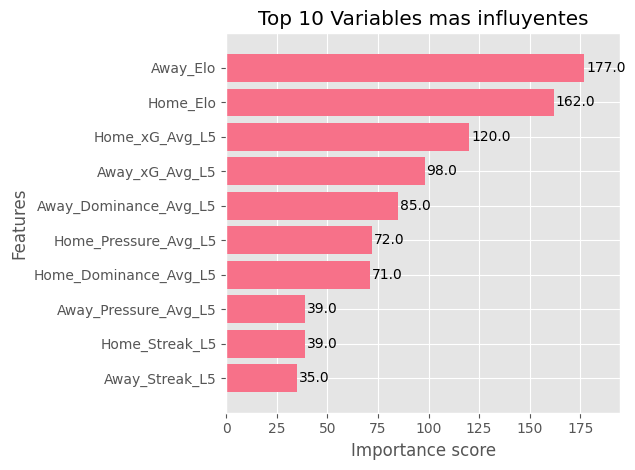

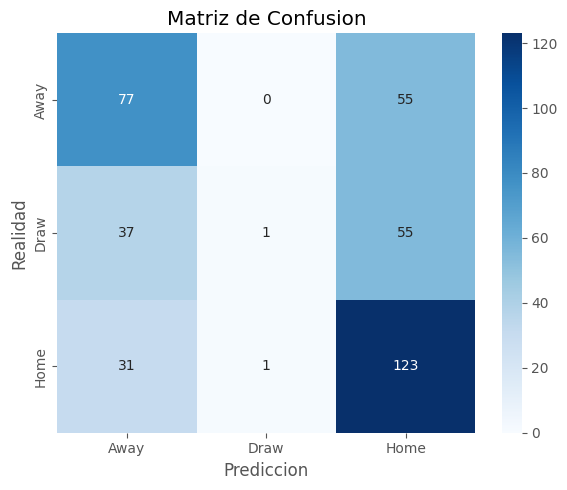

In [9]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(final_model, max_num_features=10, height=0.8, importance_type="weight")
plt.title("Top 10 Variables mas influyentes")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Away", "Draw", "Home"],
            yticklabels=["Away", "Draw", "Home"])
plt.xlabel("Prediccion")
plt.ylabel("Realidad")
plt.title("Matriz de Confusion")
plt.tight_layout()
plt.show()

## 📊 Backtest: Simulación de Apuestas

Validación financiera del modelo mediante simulación retrospectiva:
- **Apuesta plana** (10u por apuesta) vs **Kelly Criterion** (stake proporcional al edge)
- Solo se apuesta cuando **EV > 5%** (margen de seguridad)
- Se utilizan cuotas históricas de Bet365 (`B365H`, `B365D`, `B365A`)

> ⚠️ Este backtest usa el mismo dataset de entrenamiento (in-sample). Para una validación rigurosa out-of-sample, ver Notebook 03.


WALK-FORWARD BACKTEST — 10 Temporadas de Test
Ventana de entrenamiento: 5 años
Temporadas disponibles: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

--- Fold 1: Train [2010, 2011, 2012, 2013, 2014] → Test 2015 (1900 train, 380 test) ---
    Log Loss: 1.0620 | Accuracy: 0.4500
    Apuestas con EV > 5%: 322

--- Fold 2: Train [2011, 2012, 2013, 2014, 2015] → Test 2016 (1900 train, 380 test) ---
    Log Loss: 0.9307 | Accuracy: 0.6105
    Apuestas con EV > 5%: 335

--- Fold 3: Train [2012, 2013, 2014, 2015, 2016] → Test 2017 (1900 train, 380 test) ---
    Log Loss: 0.9694 | Accuracy: 0.5447
    Apuestas con EV > 5%: 329

--- Fold 4: Train [2013, 2014, 2015, 2016, 2017] → Test 2018 (1900 train, 380 test) ---
    Log Loss: 0.8990 | Accuracy: 0.5816
    Apuestas con EV > 5%: 345

--- Fold 5: Train [2014, 2015, 2016, 2017, 2018] → Test 2019 (1900 train, 380 test) ---
    Log Loss: 0.9874 | Accuracy: 0.5289
    Apuestas con EV > 5%: 306

--- Fold 

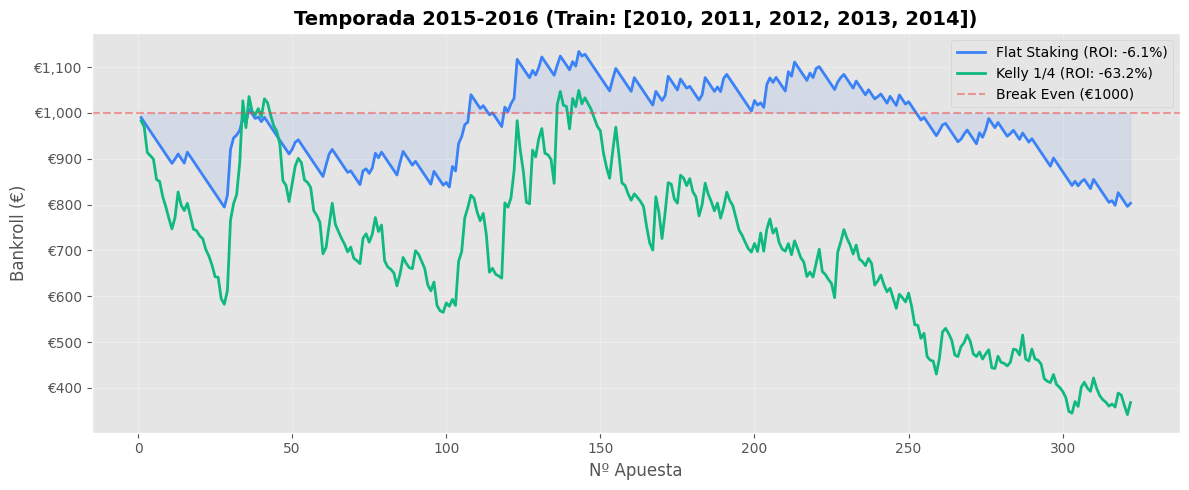


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2015-08-08 00:00:00,Bournemouth vs Aston Villa,D,3.60,17.4%,€16.73,LOSS,€-16.73
2015-08-08 00:00:00,Chelsea vs Swansea City,A,11.00,55.2%,€13.57,LOSS,€-13.57
2015-08-08 00:00:00,Everton vs Watford,H,1.70,16.1%,€55.86,LOSS,€-55.86
2015-08-08 00:00:00,Leicester City vs Sunderland,D,3.50,8.1%,€7.36,LOSS,€-7.36
2015-08-08 00:00:00,Manchester United vs Tottenham,A,6.00,15.9%,€7.20,LOSS,€-7.20
2016-05-15 00:00:00,Watford vs Sunderland,D,3.75,34.0%,€11.08,WIN,€30.48
2016-05-15 00:00:00,Stoke City vs West Ham United,D,3.60,11.5%,€4.28,LOSS,€-4.28
2016-05-15 00:00:00,Swansea City vs Manchester City,H,6.00,116.6%,€22.41,LOSS,€-22.41
2016-05-15 00:00:00,West Brom vs Liverpool,A,3.00,44.5%,€20.14,LOSS,€-20.14
2016-05-17 00:00:00,Manchester United vs Bournemouth,H,1.67,30.9%,€39.37,WIN,€26.37



────────────────────────────────────────────────────────────
TEMPORADA 2016-2017
Entrenado con: [2011, 2012, 2013, 2014, 2015]
────────────────────────────────────────────────────────────
  Apuestas: 335  |  Aciertos: 91 (27.2%)
  ROI Flat: -9.40%  |  Bankroll: €685
  ROI Kelly: -39.66%  |  Bankroll: €603

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   143    26   18.2%   -24.8%
     D    79    21   26.6%    -3.7%
     H   113    44   38.9%    +6.1%


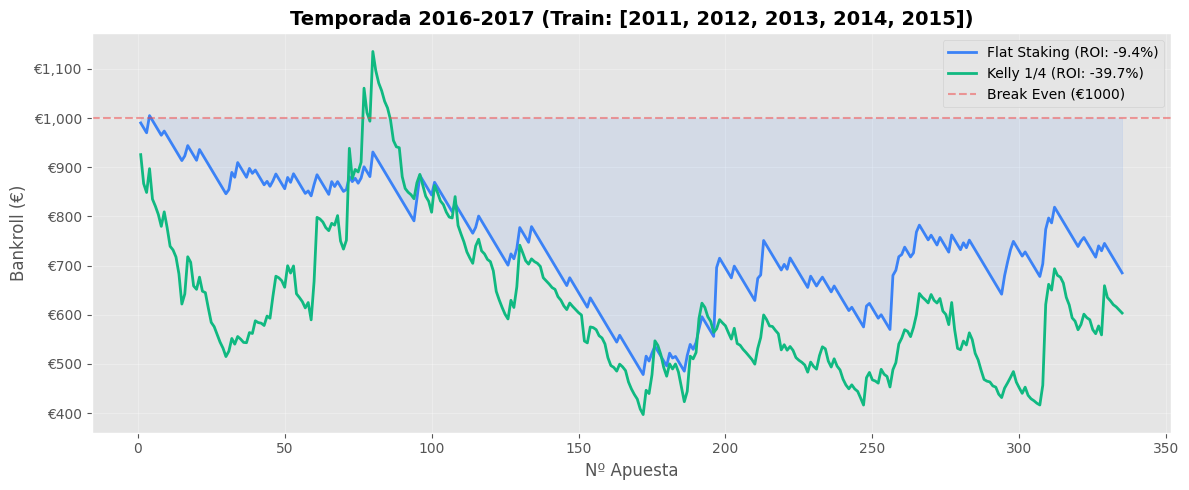


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2016-08-13 00:00:00,Southampton vs Watford,H,1.80,23.8%,€74.45,LOSS,€-74.45
2016-08-13 00:00:00,Middlesbrough vs Stoke City,A,3.40,61.1%,€58.93,LOSS,€-58.93
2016-08-13 00:00:00,Manchester City vs Sunderland,A,15.00,116.4%,€18.01,LOSS,€-18.01
2016-08-13 00:00:00,Crystal Palace vs West Brom,A,4.50,22.8%,€13.83,WIN,€48.42
2016-08-13 00:00:00,Everton vs Tottenham,A,2.40,38.7%,€62.04,LOSS,€-62.04
2017-05-21 00:00:00,Burnley vs West Ham United,D,3.50,10.5%,€6.64,LOSS,€-6.64
2017-05-21 00:00:00,Arsenal vs Everton,A,7.50,33.2%,€8.03,LOSS,€-8.03
2017-05-21 00:00:00,Hull City vs Tottenham,D,4.75,10.7%,€4.43,LOSS,€-4.43
2017-05-21 00:00:00,Chelsea vs Sunderland,A,23.00,89.3%,€6.25,LOSS,€-6.25
2017-05-21 00:00:00,Watford vs Manchester City,H,11.00,41.4%,€6.30,LOSS,€-6.30



────────────────────────────────────────────────────────────
TEMPORADA 2017-2018
Entrenado con: [2012, 2013, 2014, 2015, 2016]
────────────────────────────────────────────────────────────
  Apuestas: 329  |  Aciertos: 85 (25.8%)
  ROI Flat: +0.47%  |  Bankroll: €1016
  ROI Kelly: -61.41%  |  Bankroll: €386

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   121    26   21.5%    +5.3%
     D    87    17   19.5%   -26.4%
     H   121    42   34.7%   +14.9%


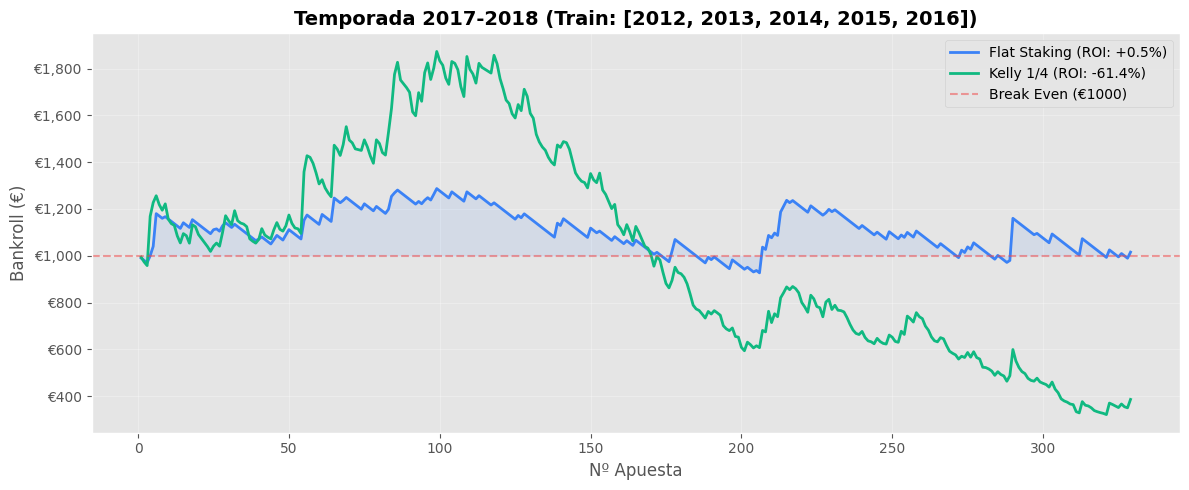


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2017-08-12 00:00:00,Watford vs Liverpool,H,6.00,11.8%,€5.88,LOSS,€-5.88
2017-08-12 00:00:00,West Brom vs Bournemouth,D,3.30,19.2%,€20.72,LOSS,€-20.72
2017-08-12 00:00:00,Everton vs Stoke City,A,5.75,30.3%,€15.55,LOSS,€-15.55
2017-08-12 00:00:00,Southampton vs Swansea City,D,4.00,88.0%,€70.28,WIN,€210.84
2017-08-12 00:00:00,Crystal Palace vs Huddersfield,A,5.00,20.0%,€14.61,WIN,€58.43
2018-05-13 00:00:00,Newcastle United vs Chelsea,D,4.20,23.2%,€6.49,LOSS,€-6.49
2018-05-13 00:00:00,West Ham United vs Everton,H,2.45,17.5%,€10.59,WIN,€15.36
2018-05-13 00:00:00,Liverpool vs Brighton,A,15.00,182.4%,€11.93,LOSS,€-11.93
2018-05-13 00:00:00,Huddersfield vs Arsenal,H,6.00,25.8%,€4.57,LOSS,€-4.57
2018-05-13 00:00:00,Burnley vs Bournemouth,A,3.60,41.1%,€13.83,WIN,€35.96



────────────────────────────────────────────────────────────
TEMPORADA 2018-2019
Entrenado con: [2013, 2014, 2015, 2016, 2017]
────────────────────────────────────────────────────────────
  Apuestas: 345  |  Aciertos: 114 (33.0%)
  ROI Flat: +8.04%  |  Bankroll: €1278
  ROI Kelly: +233.90%  |  Bankroll: €3339

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   131    37   28.2%    +5.6%
     D    72    18   25.0%    +1.7%
     H   142    59   41.5%   +13.5%


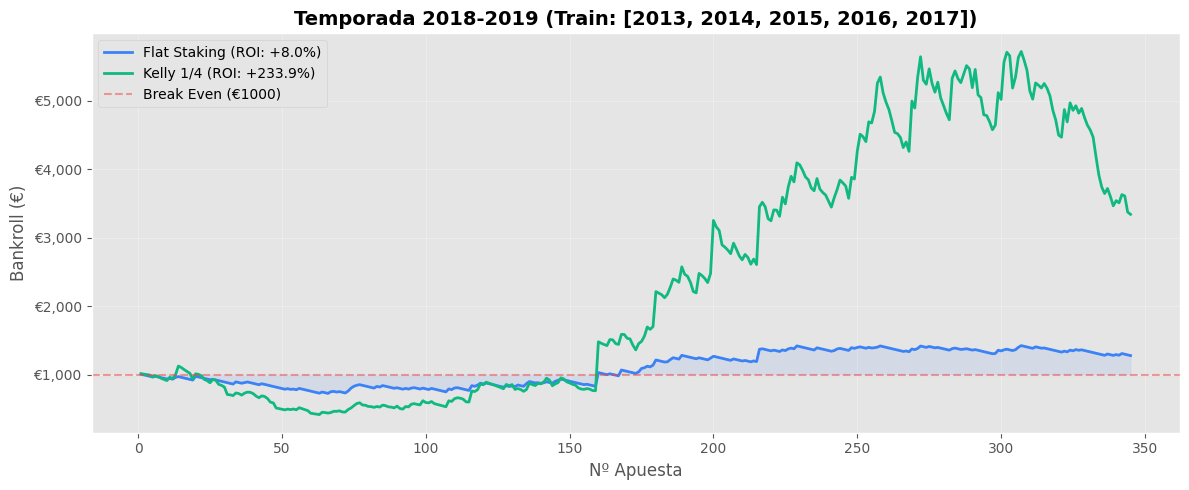


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2018-08-10 00:00:00,Manchester United vs Leicester City,H,1.57,5.5%,€23.95,WIN,€13.65
2018-08-11 00:00:00,Wolverhampton vs Everton,A,3.30,6.8%,€7.55,LOSS,€-7.55
2018-08-11 00:00:00,Newcastle United vs Tottenham,H,3.90,7.0%,€6.07,LOSS,€-6.07
2018-08-11 00:00:00,Watford vs Brighton,A,3.40,6.4%,€6.64,LOSS,€-6.64
2018-08-11 00:00:00,Fulham vs Crystal Palace,D,3.40,27.9%,€28.91,LOSS,€-28.91
2019-05-12 00:00:00,Southampton vs Huddersfield,A,8.50,26.6%,€31.33,LOSS,€-31.33
2019-05-12 00:00:00,Tottenham vs Everton,D,3.50,13.7%,€47.98,WIN,€119.96
2019-05-12 00:00:00,Watford vs West Ham United,D,3.75,5.9%,€19.44,LOSS,€-19.44
2019-05-12 00:00:00,Liverpool vs Wolverhampton,A,11.00,260.7%,€235.14,LOSS,€-235.14
2019-05-12 00:00:00,Brighton vs Manchester City,H,19.00,71.1%,€33.32,LOSS,€-33.32



────────────────────────────────────────────────────────────
TEMPORADA 2019-2020
Entrenado con: [2014, 2015, 2016, 2017, 2018]
────────────────────────────────────────────────────────────
  Apuestas: 306  |  Aciertos: 104 (34.0%)
  ROI Flat: +8.95%  |  Bankroll: €1274
  ROI Kelly: -10.11%  |  Bankroll: €899

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A    85    20   23.5%    +3.8%
     D    60    15   25.0%    -0.2%
     H   161    69   42.9%   +15.1%


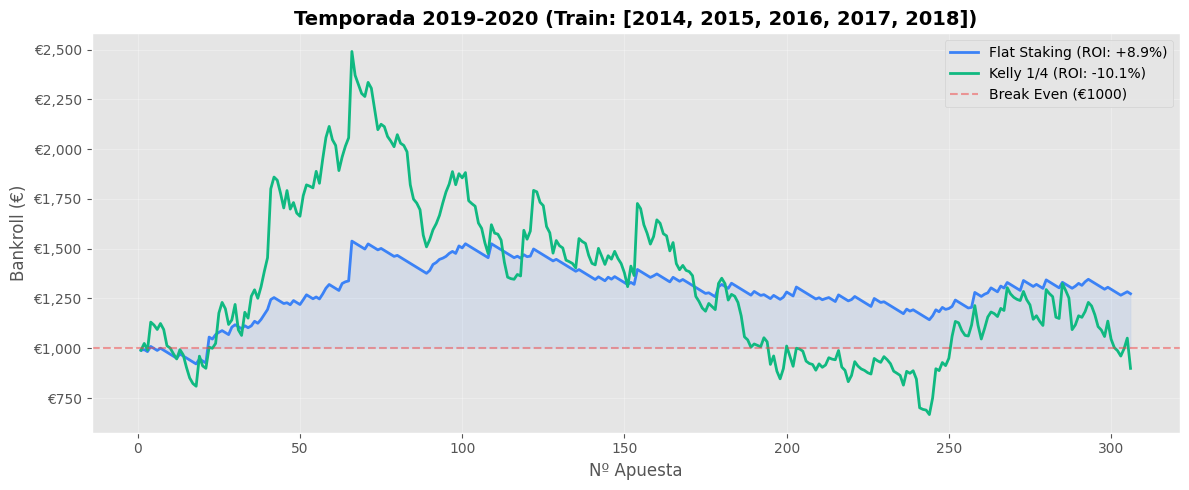


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2019-08-09 00:00:00,Liverpool vs Norwich City,A,19.00,72.2%,€10.03,LOSS,€-10.03
2019-08-10 00:00:00,Tottenham vs Aston Villa,H,1.30,13.8%,€113.61,WIN,€34.08
2019-08-10 00:00:00,Watford vs Brighton,H,1.90,11.9%,€33.85,LOSS,€-33.85
2019-08-10 00:00:00,Bournemouth vs Sheffield Utd,D,3.60,57.0%,€54.23,WIN,€141.00
2019-08-10 00:00:00,West Ham United vs Manchester City,D,6.50,28.4%,€14.62,LOSS,€-14.62
2020-07-26 00:00:00,Leicester City vs Manchester United,H,3.25,14.1%,€15.77,LOSS,€-15.77
2020-07-26 00:00:00,Burnley vs Brighton,H,2.37,14.9%,€26.94,LOSS,€-26.94
2020-07-26 00:00:00,Arsenal vs Watford,H,1.90,15.2%,€40.69,WIN,€36.62
2020-07-26 00:00:00,Chelsea vs Wolverhampton,H,1.85,21.4%,€62.90,WIN,€53.47
2020-07-26 00:00:00,West Ham United vs Aston Villa,H,3.00,115.6%,€151.85,LOSS,€-151.85



────────────────────────────────────────────────────────────
TEMPORADA 2020-2021
Entrenado con: [2015, 2016, 2017, 2018, 2019]
────────────────────────────────────────────────────────────
  Apuestas: 328  |  Aciertos: 94 (28.7%)
  ROI Flat: -16.70%  |  Bankroll: €452
  ROI Kelly: -91.51%  |  Bankroll: €85

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A    55    20   36.4%   +22.0%
     D    91    18   19.8%   -26.8%
     H   182    56   30.8%   -23.3%


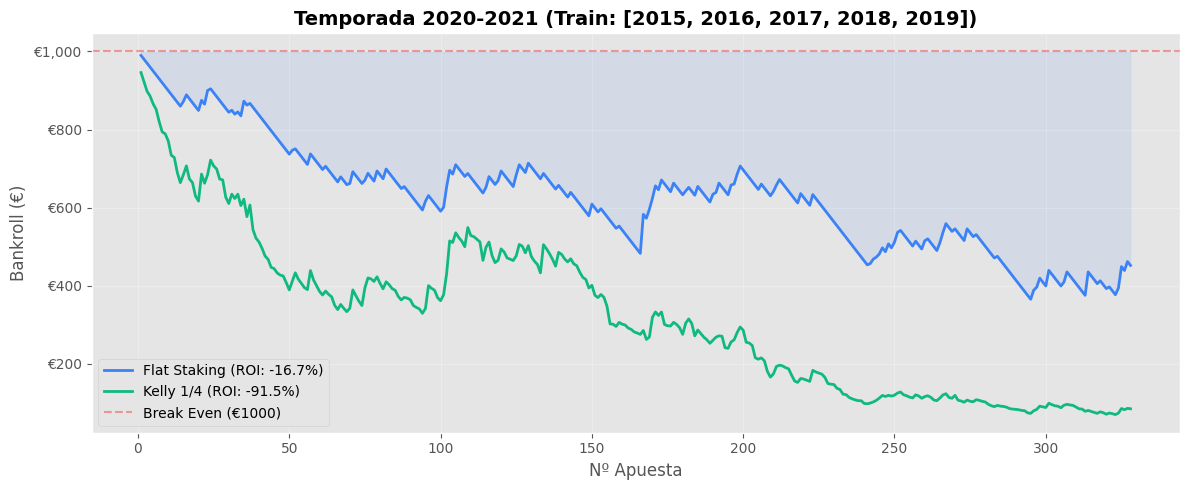


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2020-09-12 00:00:00,Fulham vs Arsenal,H,6.00,108.0%,€54.02,LOSS,€-54.02
2020-09-12 00:00:00,Crystal Palace vs Southampton,A,2.37,13.8%,€23.79,LOSS,€-23.79
2020-09-12 00:00:00,Liverpool vs Leeds United,D,6.00,51.9%,€23.95,LOSS,€-23.95
2020-09-12 00:00:00,West Ham United vs Newcastle United,D,3.40,13.3%,€12.44,LOSS,€-12.44
2020-09-13 00:00:00,Tottenham vs Everton,D,3.60,23.2%,€19.75,LOSS,€-19.75
2021-05-23 00:00:00,Wolverhampton vs Manchester United,A,2.70,21.2%,€2.18,WIN,€3.71
2021-05-23 00:00:00,Aston Villa vs Chelsea,H,6.50,63.8%,€2.14,WIN,€11.77
2021-05-23 00:00:00,Arsenal vs Brighton,D,4.33,47.6%,€3.06,LOSS,€-3.06
2021-05-23 00:00:00,Fulham vs Newcastle United,A,3.30,16.7%,€1.50,WIN,€3.46
2021-05-23 00:00:00,Liverpool vs Crystal Palace,A,15.00,73.8%,€1.13,LOSS,€-1.13



────────────────────────────────────────────────────────────
TEMPORADA 2021-2022
Entrenado con: [2016, 2017, 2018, 2019, 2020]
────────────────────────────────────────────────────────────
  Apuestas: 313  |  Aciertos: 79 (25.2%)
  ROI Flat: -13.24%  |  Bankroll: €586
  ROI Kelly: -78.39%  |  Bankroll: €216

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   125    28   22.4%   -14.6%
     D    45    12   26.7%    +6.1%
     H   143    39   27.3%   -18.2%


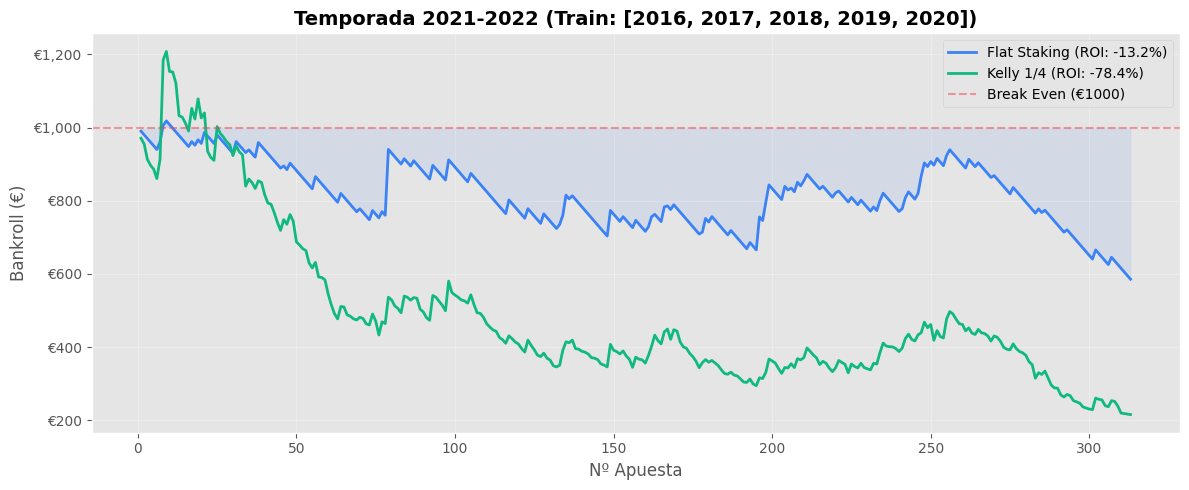


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2021-08-14 00:00:00,Manchester United vs Leeds United,D,4.50,41.2%,€29.42,LOSS,€-29.42
2021-08-14 00:00:00,Chelsea vs Crystal Palace,A,13.00,76.3%,€15.43,LOSS,€-15.43
2021-08-14 00:00:00,Burnley vs Brighton,H,3.10,36.9%,€42.00,LOSS,€-42.00
2021-08-14 00:00:00,Norwich City vs Liverpool,D,5.75,33.8%,€16.26,LOSS,€-16.26
2021-08-14 00:00:00,Everton vs Southampton,A,4.00,14.6%,€10.94,LOSS,€-10.94
2022-05-22 00:00:00,Norwich City vs Tottenham,H,9.50,172.7%,€12.80,LOSS,€-12.80
2022-05-22 00:00:00,Brentford vs Leeds United,H,2.45,46.0%,€18.97,LOSS,€-18.97
2022-05-22 00:00:00,Arsenal vs Everton,A,9.00,20.0%,€1.38,LOSS,€-1.38
2022-05-22 00:00:00,Burnley vs Newcastle United,D,3.40,7.1%,€1.62,LOSS,€-1.62
2022-05-22 00:00:00,Liverpool vs Wolverhampton,A,15.00,29.1%,€1.13,LOSS,€-1.13



────────────────────────────────────────────────────────────
TEMPORADA 2022-2023
Entrenado con: [2017, 2018, 2019, 2020, 2021]
────────────────────────────────────────────────────────────
  Apuestas: 288  |  Aciertos: 74 (25.7%)
  ROI Flat: -7.12%  |  Bankroll: €795
  ROI Kelly: -51.97%  |  Bankroll: €480

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   127    27   21.3%   -15.8%
     D    65    11   16.9%   -31.3%
     H    96    36   37.5%   +20.7%


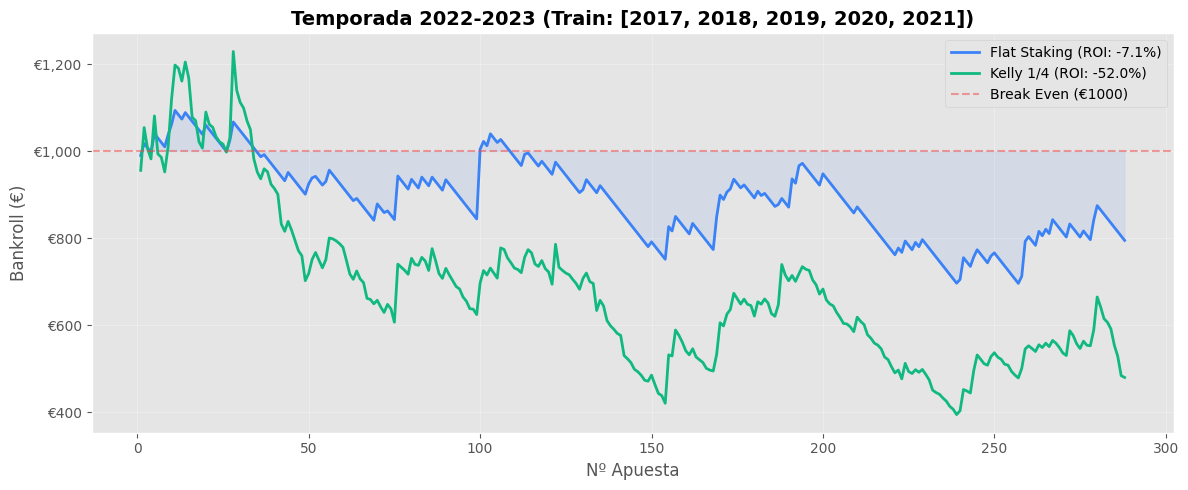


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2022-08-06 00:00:00,Leeds United vs Wolverhampton,D,3.40,42.4%,€44.16,LOSS,€-44.16
2022-08-06 00:00:00,Bournemouth vs Aston Villa,H,3.75,41.1%,€35.73,WIN,€98.25
2022-08-06 00:00:00,Newcastle United vs Nott. Forest,D,3.80,51.5%,€48.50,LOSS,€-48.50
2022-08-07 00:00:00,Leicester City vs Brentford,H,2.00,9.3%,€23.43,LOSS,€-23.43
2022-08-07 00:00:00,Manchester United vs Brighton,A,5.25,40.2%,€23.20,WIN,€98.61
2023-05-28 00:00:00,Everton vs Bournemouth,A,6.50,54.3%,€14.99,LOSS,€-14.99
2023-05-28 00:00:00,Brentford vs Manchester City,A,1.83,21.0%,€37.45,LOSS,€-37.45
2023-05-28 00:00:00,Southampton vs Liverpool,A,1.44,8.1%,€25.53,LOSS,€-25.53
2023-05-28 00:00:00,Chelsea vs Newcastle United,A,2.38,46.4%,€44.49,LOSS,€-44.49
2023-05-28 00:00:00,Arsenal vs Wolverhampton,A,8.00,23.7%,€4.11,LOSS,€-4.11



────────────────────────────────────────────────────────────
TEMPORADA 2023-2024
Entrenado con: [2018, 2019, 2020, 2021, 2022]
────────────────────────────────────────────────────────────
  Apuestas: 302  |  Aciertos: 78 (25.8%)
  ROI Flat: -20.84%  |  Bankroll: €371
  ROI Kelly: -70.29%  |  Bankroll: €297

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   146    34   23.3%   -26.0%
     D    50     9   18.0%   -31.4%
     H   106    35   33.0%    -8.7%


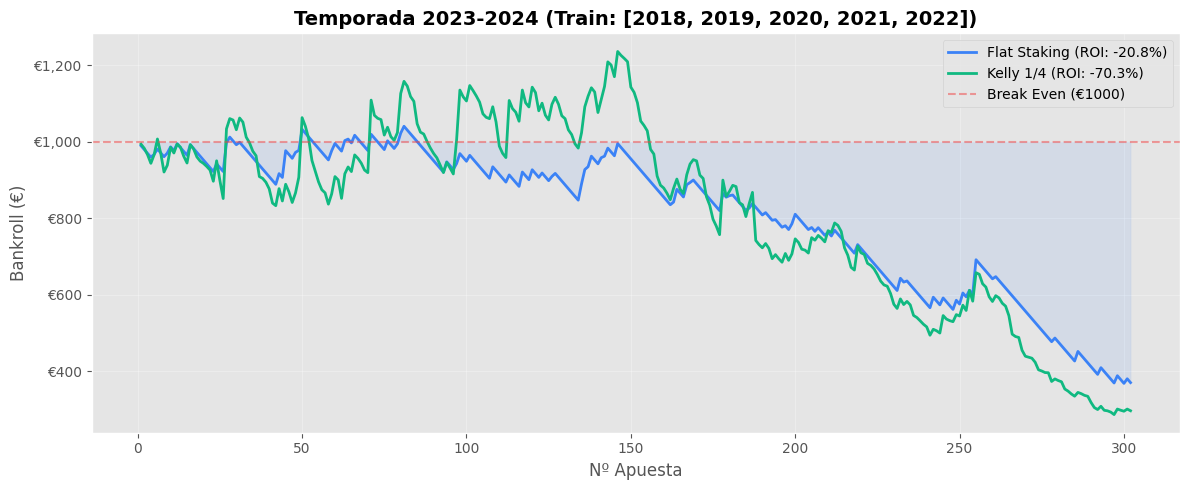


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2023-08-11 00:00:00,Burnley vs Manchester City,H,8.00,16.5%,€5.89,LOSS,€-5.89
2023-08-12 00:00:00,Arsenal vs Nott. Forest,A,15.00,61.4%,€10.89,LOSS,€-10.89
2023-08-12 00:00:00,Brighton vs Luton,A,9.00,55.1%,€16.93,LOSS,€-16.93
2023-08-12 00:00:00,Bournemouth vs West Ham United,A,2.55,14.3%,€22.33,LOSS,€-22.33
2023-08-12 00:00:00,Newcastle United vs Aston Villa,H,1.75,9.6%,€30.34,WIN,€22.76
2024-05-19 00:00:00,Brighton vs Manchester United,A,2.90,20.1%,€7.59,WIN,€14.43
2024-05-19 00:00:00,Arsenal vs Everton,D,8.00,28.6%,€3.08,LOSS,€-3.08
2024-05-19 00:00:00,Chelsea vs Bournemouth,A,6.00,17.3%,€2.59,LOSS,€-2.59
2024-05-19 00:00:00,Luton vs Fulham,A,2.20,7.5%,€4.65,WIN,€5.58
2024-05-19 00:00:00,Crystal Palace vs Aston Villa,D,4.33,19.4%,€4.39,LOSS,€-4.39



────────────────────────────────────────────────────────────
TEMPORADA 2024-2025
Entrenado con: [2019, 2020, 2021, 2022, 2023]
────────────────────────────────────────────────────────────
  Apuestas: 329  |  Aciertos: 113 (34.3%)
  ROI Flat: -4.24%  |  Bankroll: €860
  ROI Kelly: -89.37%  |  Bankroll: €106

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   156    56   35.9%    +8.7%
     D    32     9   28.1%   +32.8%
     H   141    48   34.0%   -27.0%


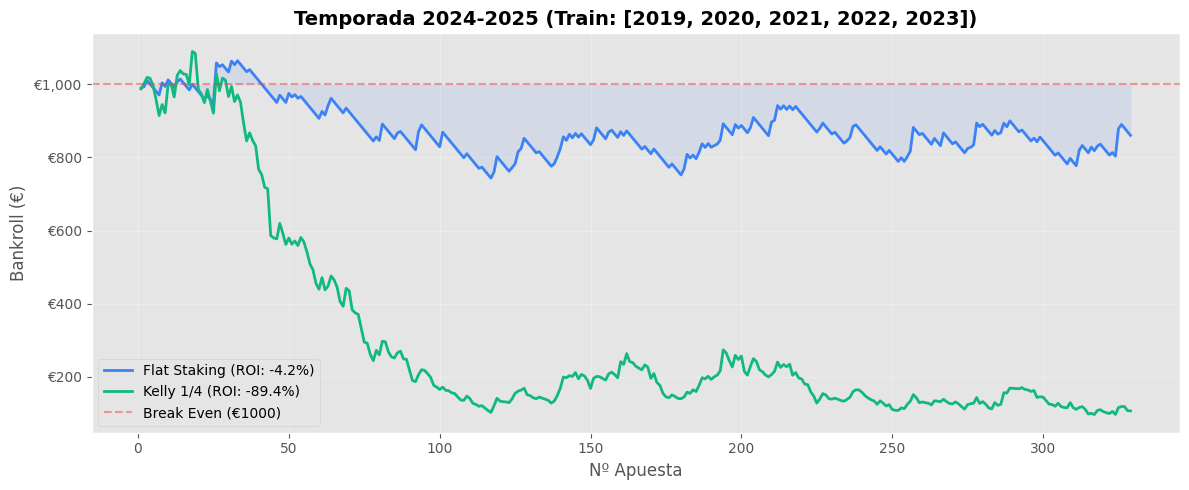


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2024-08-17 00:00:00,Everton vs Brighton,H,2.63,8.0%,€12.30,LOSS,€-12.30
2024-08-17 00:00:00,Newcastle United vs Southampton,H,1.36,5.7%,€38.90,WIN,€14.00
2024-08-17 00:00:00,West Ham United vs Aston Villa,A,2.75,7.0%,€10.06,WIN,€17.61
2024-08-17 00:00:00,Arsenal vs Wolverhampton,A,13.00,12.0%,€2.54,LOSS,€-2.54
2024-08-17 00:00:00,Ipswich vs Liverpool,H,8.50,58.9%,€19.96,LOSS,€-19.96
2025-05-25 00:00:00,Newcastle United vs Everton,A,8.50,77.8%,€2.51,WIN,€18.82
2025-05-25 00:00:00,Nott. Forest vs Chelsea,A,2.20,10.0%,€2.41,WIN,€2.89
2025-05-25 00:00:00,Southampton vs Arsenal,H,8.50,5.5%,€0.22,LOSS,€-0.22
2025-05-25 00:00:00,Manchester United vs Aston Villa,A,1.70,26.0%,€10.98,LOSS,€-10.98
2025-05-25 00:00:00,Wolverhampton vs Brentford,A,2.45,5.0%,€0.93,LOSS,€-0.93



RESUMEN GLOBAL — TODAS LAS TEMPORADAS


,bets,wins,hit_rate,flat_roi,flat_final,kelly_roi,kelly_final
season,,,,,,,
2015,322,105,32.6,-6.12,803.0,-63.18,368.0
2016,335,91,27.2,-9.40,685.0,-39.66,603.0
2017,329,85,25.8,0.47,1016.0,-61.41,386.0
2018,345,114,33.0,8.04,1278.0,233.90,3339.0
2019,306,104,34.0,8.95,1274.0,-10.11,899.0
2020,328,94,28.7,-16.70,452.0,-91.51,85.0
2021,313,79,25.2,-13.24,586.0,-78.39,216.0
2022,288,74,25.7,-7.12,795.0,-51.97,480.0
2023,302,78,25.8,-20.84,371.0,-70.29,297.0



Media ROI Flat: -6.02%
Total apuestas: 3197
Total aciertos: 937 (29.3%)


In [10]:
# ============================================================
# BACKTEST: Walk-Forward por Temporadas con Apuestas Combinadas
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import log_loss, accuracy_score

# --- Configuración ---
INITIAL_BANKROLL = 1000
FLAT_STAKE = 10
MIN_EV = 0.05        # Solo apostar si EV > 5%
KELLY_FRACTION = 0.25 # Cuarto Kelly (más conservador)
WINDOW_SIZE = 5       # Años de entrenamiento

# --- Preparar datos ---
df_bt = df.copy()

# DEDUPLICAR: Season 2024 contiene filas duplicadas (3040 vs 380 esperadas)
# Identificamos duplicados por Date + HomeTeam + AwayTeam y nos quedamos con el primero
before = len(df_bt)
df_bt = df_bt.drop_duplicates(subset=['Date', 'HomeTeam', 'AwayTeam'], keep='first')
after = len(df_bt)
if before != after:
    print(f"⚠️ Se eliminaron {before - after} filas duplicadas ({before} → {after})")

odds_cols = ['B365H', 'B365D', 'B365A']

# Verificar que las cuotas existen
has_odds = all(c in df_bt.columns for c in odds_cols)
if not has_odds:
    print('⚠️ Columnas de cuotas B365 no encontradas. Backtest no disponible.')
else:
    # Eliminar filas sin cuotas
    df_bt = df_bt.dropna(subset=odds_cols + features + ['Target'])
    df_bt = df_bt.sort_values('Date').reset_index(drop=True)
    
    # --- Walk-Forward por Temporadas ---
    seasons_bt = sorted(df_bt['Season'].unique())
    n_folds = len(seasons_bt) - WINDOW_SIZE
    
    print(f"\n{'='*60}")
    print(f"WALK-FORWARD BACKTEST — {n_folds} Temporadas de Test")
    print(f"Ventana de entrenamiento: {WINDOW_SIZE} años")
    print(f"Temporadas disponibles: {seasons_bt}")
    print(f"{'='*60}")
    
    all_season_results = {}  # dict: season -> list of bet results
    
    for fold_i in range(n_folds):
        fold = fold_i + 1
        train_seasons = seasons_bt[fold_i : fold_i + WINDOW_SIZE]
        test_season   = seasons_bt[fold_i + WINDOW_SIZE]
        
        train_mask = df_bt['Season'].isin(train_seasons)
        test_mask  = df_bt['Season'] == test_season
        
        X_train_f = df_bt.loc[train_mask, features].astype(float)
        y_train_f = df_bt.loc[train_mask, 'Target'].astype(int)
        X_test_f  = df_bt.loc[test_mask,  features].astype(float)
        y_test_f  = df_bt.loc[test_mask,  'Target'].astype(int)
        
        n_train = len(X_train_f)
        n_test  = len(X_test_f)
        
        # --- Entrenar modelo ---
        _params = best_params if 'best_params' in dir() else {
            'objective': 'multi:softprob', 'num_class': 3, 'max_depth': 4,
            'learning_rate': 0.05, 'n_estimators': 150, 'random_state': 42
        }
        bt_model = xgb.XGBClassifier(**_params)
        bt_model.fit(X_train_f, y_train_f)
        
        # --- Predecir ---
        proba = bt_model.predict_proba(X_test_f)
        preds = bt_model.predict(X_test_f)
        ll = log_loss(y_test_f, proba)
        acc = accuracy_score(y_test_f, preds)
        
        print(f"\n--- Fold {fold}: Train {train_seasons} → Test {int(test_season)} "
              f"({n_train} train, {n_test} test) ---")
        print(f"    Log Loss: {ll:.4f} | Accuracy: {acc:.4f}")
        
        # --- Evaluar apuestas ---
        test_indices = df_bt.index[test_mask].tolist()
        season_results = []
        
        for j, idx in enumerate(test_indices):
            row = df_bt.iloc[idx]
            p_A, p_D, p_H = proba[j]  # Mapping: A=0, D=1, H=2
            
            odds_H = row['B365H']
            odds_D = row['B365D']
            odds_A = row['B365A']
            actual = int(row['Target'])  # 0=A, 1=D, 2=H
            
            # === APUESTAS SIMPLES ===
            bets = []
            # Home win
            bets.append(('H', p_H, odds_H, actual == 2))
            # Draw
            bets.append(('D', p_D, odds_D, actual == 1))
            # Away win
            bets.append(('A', p_A, odds_A, actual == 0))
            
            # === APUESTAS COMBINADAS (Doble Oportunidad) ===
            # 1X = Home o Draw
            p_1X = p_H + p_D
            odds_1X = 1.0 / (1.0/odds_H + 1.0/odds_D)
            bets.append(('1X', p_1X, odds_1X, actual in (1, 2)))
            
            # X2 = Draw o Away
            p_X2 = p_D + p_A
            odds_X2 = 1.0 / (1.0/odds_D + 1.0/odds_A)
            bets.append(('X2', p_X2, odds_X2, actual in (0, 1)))
            
            # 12 = Home o Away
            p_12 = p_H + p_A
            odds_12 = 1.0 / (1.0/odds_H + 1.0/odds_A)
            bets.append(('12', p_12, odds_12, actual in (0, 2)))
            
            # --- Calcular EV y elegir la mejor ---
            best_bet = None
            best_ev_val = -999
            for (bet_name, prob, odds_val, won) in bets:
                ev = (prob * odds_val) - 1
                if ev > best_ev_val:
                    best_ev_val = ev
                    best_bet = (bet_name, prob, odds_val, won, ev)
            
            if best_bet is not None and best_ev_val > MIN_EV:
                bet_name, prob, odds_val, won, ev = best_bet
                kelly = max(0, (prob * odds_val - 1) / (odds_val - 1)) * KELLY_FRACTION
                
                season_results.append({
                    'date': row['Date'],
                    'home': row.get('HomeTeam', ''),
                    'away': row.get('AwayTeam', ''),
                    'bet': bet_name,
                    'odds': odds_val,
                    'prob': prob,
                    'ev': ev,
                    'won': won,
                    'kelly_pct': kelly,
                    'fold': fold
                })
        
        all_season_results[int(test_season)] = season_results
        print(f"    Apuestas con EV > {MIN_EV*100:.0f}%: {len(season_results)}")

    # ================================================================
    # GRÁFICAS POR TEMPORADA
    # ================================================================
    print(f"\n{'='*60}")
    print("RESULTADOS POR TEMPORADA")
    print(f"{'='*60}")
    
    global_summary = []
    
    for season_year in sorted(all_season_results.keys()):
        results = all_season_results[season_year]
        if not results:
            print(f"\nTemporada {season_year}: Sin apuestas con EV > {MIN_EV*100:.0f}%")
            continue
        
        df_res = pd.DataFrame(results)
        df_res['date'] = pd.to_datetime(df_res['date'])
        df_res = df_res.sort_values('date').reset_index(drop=True)
        
        # Flat staking P&L
        df_res['flat_pnl'] = df_res.apply(
            lambda r: FLAT_STAKE * (r['odds'] - 1) if r['won'] else -FLAT_STAKE, axis=1
        )
        df_res['flat_cumsum'] = INITIAL_BANKROLL + df_res['flat_pnl'].cumsum()
        
        # Kelly P&L
        kelly_bank = INITIAL_BANKROLL
        kelly_curve = []
        kelly_stakes = []
        
        for _, r in df_res.iterrows():
            stake = kelly_bank * r['kelly_pct']
            kelly_stakes.append(stake)
            if r['won']:
                kelly_bank += stake * (r['odds'] - 1)
            else:
                kelly_bank -= stake
            kelly_curve.append(kelly_bank)
        
        df_res['kelly_cumsum'] = kelly_curve
        df_res['kelly_stake'] = kelly_stakes
        
        # --- Métricas ---
        total_bets = len(df_res)
        wins = int(df_res['won'].sum())
        hit_rate = wins / total_bets * 100
        flat_roi = df_res['flat_pnl'].sum() / (total_bets * FLAT_STAKE) * 100
        kelly_roi = (kelly_bank - INITIAL_BANKROLL) / INITIAL_BANKROLL * 100
        flat_final = df_res['flat_cumsum'].iloc[-1]
        
        # Desglose por tipo de apuesta
        bet_breakdown = df_res.groupby('bet').agg(
            n=('won', 'count'),
            wins=('won', 'sum'),
            pnl=('flat_pnl', 'sum')
        )
        bet_breakdown['hit'] = (bet_breakdown['wins'] / bet_breakdown['n'] * 100).round(1)
        bet_breakdown['roi'] = (bet_breakdown['pnl'] / (bet_breakdown['n'] * FLAT_STAKE) * 100).round(1)
        
        # Temporadas de entrenamiento usadas
        fold_idx = season_year - seasons_bt[WINDOW_SIZE]
        train_used = seasons_bt[fold_idx : fold_idx + WINDOW_SIZE]
        
        print(f"\n{'─'*60}")
        print(f"TEMPORADA {season_year}-{season_year+1}")
        print(f"Entrenado con: {list(map(int, train_used))}")
        print(f"{'─'*60}")
        print(f"  Apuestas: {total_bets}  |  Aciertos: {wins} ({hit_rate:.1f}%)")
        print(f"  ROI Flat: {flat_roi:+.2f}%  |  Bankroll: €{flat_final:.0f}")
        print(f"  ROI Kelly: {kelly_roi:+.2f}%  |  Bankroll: €{kelly_bank:.0f}")
        print(f"\n  Desglose por tipo de apuesta:")
        print(f"  {'Tipo':>4s}  {'N':>4s}  {'Wins':>4s}  {'Hit%':>6s}  {'ROI%':>7s}")
        for bt_name, bt_row in bet_breakdown.iterrows():
            print(f"  {bt_name:>4s}  {int(bt_row['n']):>4d}  {int(bt_row['wins']):>4d}  "
                  f"{bt_row['hit']:>5.1f}%  {bt_row['roi']:>+6.1f}%")
        
        global_summary.append({
            'season': f"{season_year}",
            'bets': total_bets,
            'wins': wins,
            'hit_rate': round(hit_rate, 1),
            'flat_roi': round(flat_roi, 2),
            'flat_final': round(flat_final, 0),
            'kelly_roi': round(kelly_roi, 2),
            'kelly_final': round(kelly_bank, 0)
        })
        
        # === GRÁFICA POR TEMPORADA ===
        fig, ax = plt.subplots(figsize=(12, 5))
        
        bet_numbers = range(1, total_bets + 1)
        
        ax.plot(bet_numbers, df_res['flat_cumsum'], 
                label=f'Flat Staking (ROI: {flat_roi:+.1f}%)', 
                color='#3b82f6', linewidth=2)
        ax.plot(bet_numbers, df_res['kelly_cumsum'], 
                label=f'Kelly 1/4 (ROI: {kelly_roi:+.1f}%)', 
                color='#10b981', linewidth=2)
        ax.axhline(y=INITIAL_BANKROLL, color='#ef4444', linestyle='--', 
                   alpha=0.5, label='Break Even (€1000)')
        ax.fill_between(bet_numbers, INITIAL_BANKROLL, df_res['flat_cumsum'], 
                        alpha=0.1, color='#3b82f6')
        
        ax.set_title(f'Temporada {season_year}-{season_year+1} '
                     f'(Train: {list(map(int, train_used))})', 
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Nº Apuesta')
        ax.set_ylabel('Bankroll (€)')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('€{x:,.0f}'))
        plt.tight_layout()
        plt.show()

        # === TABLA DETALLE DE APUESTAS ===
        print(f"\n  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<")
        df_disp = df_res.copy()
        df_disp['Match'] = df_disp['home'] + ' vs ' + df_disp['away']
        df_disp['Result'] = df_disp['won'].map({True: 'WIN', False: 'LOSS'})
        df_disp['Profit'] = df_disp.apply(lambda r: r['kelly_stake'] * (r['odds'] - 1) if r['won'] else -r['kelly_stake'], axis=1)
        
        cols_show = ['date', 'Match', 'bet', 'odds', 'ev', 'kelly_stake', 'Result', 'Profit']
        
        # Formato para mostrar
        format_dict = {'ev': '{:.1%}', 'kelly_stake': '€{:.2f}', 'Profit': '€{:.2f}', 'odds': '{:.2f}'}
        
        if len(df_disp) > 10:
            df_show = pd.concat([df_disp[cols_show].head(5), df_disp[cols_show].tail(5)])
        else:
            df_show = df_disp[cols_show]
            
        # Check if we are in an IPython environment for display(), else print
        try:
             # Just simple styling if display is available (it is in Jupyter)
             display(df_show.style.format(format_dict).hide(axis='index'))
        except:
             print(df_show.to_string())

    # === TABLA RESUMEN GLOBAL ===
    if global_summary:
        print(f"\n{'='*60}")
        print("RESUMEN GLOBAL — TODAS LAS TEMPORADAS")
        print(f"{'='*60}")
        df_summary = pd.DataFrame(global_summary)
        display(df_summary.set_index('season'))
        
        avg_roi = df_summary['flat_roi'].mean()
        total_bets_all = df_summary['bets'].sum()
        total_wins_all = df_summary['wins'].sum()
        print(f"\nMedia ROI Flat: {avg_roi:+.2f}%")
        print(f"Total apuestas: {total_bets_all}")
        print(f"Total aciertos: {total_wins_all} ({total_wins_all/total_bets_all*100:.1f}%)")


## 📊 Backtest: Simulación de Apuestas

Validación financiera del modelo mediante simulación retrospectiva:
- **Apuesta plana** (10u por apuesta) vs **Kelly Criterion** (stake proporcional al edge)
- Solo se apuesta cuando **EV > 5%** (margen de seguridad)
- Se utilizan cuotas históricas de Bet365 (`B365H`, `B365D`, `B365A`)

> ⚠️ Este backtest usa el mismo dataset de entrenamiento (in-sample). Para una validación rigurosa out-of-sample, ver Notebook 03.

In [13]:
# [CELDA ELIMINADA — Backtest consolidado en celda anterior]
